## 1. Chargement et préparation des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
COLORS = sns.color_palette('Set2')

print(' Chargement du fichier parquet...')
df = pd.read_parquet('data/logs_export.parquet')

print(f' Données chargées : {len(df):,} lignes')
print(f'\n Colonnes disponibles :')
print(df.columns.tolist())
print(f'\n Aperçu des données :')
df.head(3)

 Chargement du fichier parquet...
 Données chargées : 11,997,652 lignes

 Colonnes disponibles :
['raw_log']

 Aperçu des données :


,raw_log
0,2025-03-20 01:29:24;94.102.61.47;159.84.146.99...
1,2025-03-20 01:29:25;176.111.174.85;159.84.146....
2,2025-03-20 01:29:27;66.249.65.106;159.84.146.9...


In [ ]:
#   faire le split en differents colonnes  

df = df["raw_log"].str.split(";", expand=True) 


df.columns = ["timestamp", "src_ip", "dst_ip", "protocole", "src_port", "dst_port", "taille", "action", "interface", "col10", "col11"] 

df.head()

,timestamp,src_ip,dst_ip,protocole,src_port,dst_port,taille,action,interface,col10,col11
0,2025-03-20 01:29:24,94.102.61.47,159.84.146.99,TCP,52502,3178,999,DENY,eth0,,6\n
1,2025-03-20 01:29:25,176.111.174.85,159.84.146.99,TCP,48739,2231,999,DENY,eth0,,6\n
2,2025-03-20 01:29:27,66.249.65.106,159.84.146.99,TCP,50501,443,1,PERMIT,eth0,,6\n


In [10]:
df = df.drop(columns=["col10", "col11"])

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4572903 entries, 7424749 to 11997651
Data columns (total 9 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[us]
 1   src_ip     str           
 2   dst_ip     str           
 3   protocole  str           
 4   src_port   str           
 5   dst_port   str           
 6   taille     str           
 7   action     str           
 8   interface  str           
dtypes: datetime64[us](1), str(8)
memory usage: 527.5 MB


In [12]:
df['protocole'].value_counts()

protocole
TCP    4572903
Name: count, dtype: int64

In [8]:
# ── Filtrage : novembre 2025 → février 2026 ────────────────────────────────
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
mask = (df['timestamp'] >= '2025-11-01') & (df['timestamp'] < '2026-03-01')
df_filtered= df.loc[mask]
print(f' Données après filtrage : {len(df_filtered):,} lignes')

 Données après filtrage : 4,572,903 lignes


In [19]:
df_filtered['dst_port'].value_counts()

dst_port
443    3621944
22       65661
80       38756
23       38074
445      20301
        ...   
747          1
723          1
542          1
424          1
358          1
Name: count, Length: 65532, dtype: int64

---
## Chapitre 1 — Classement des règles les plus utilisées

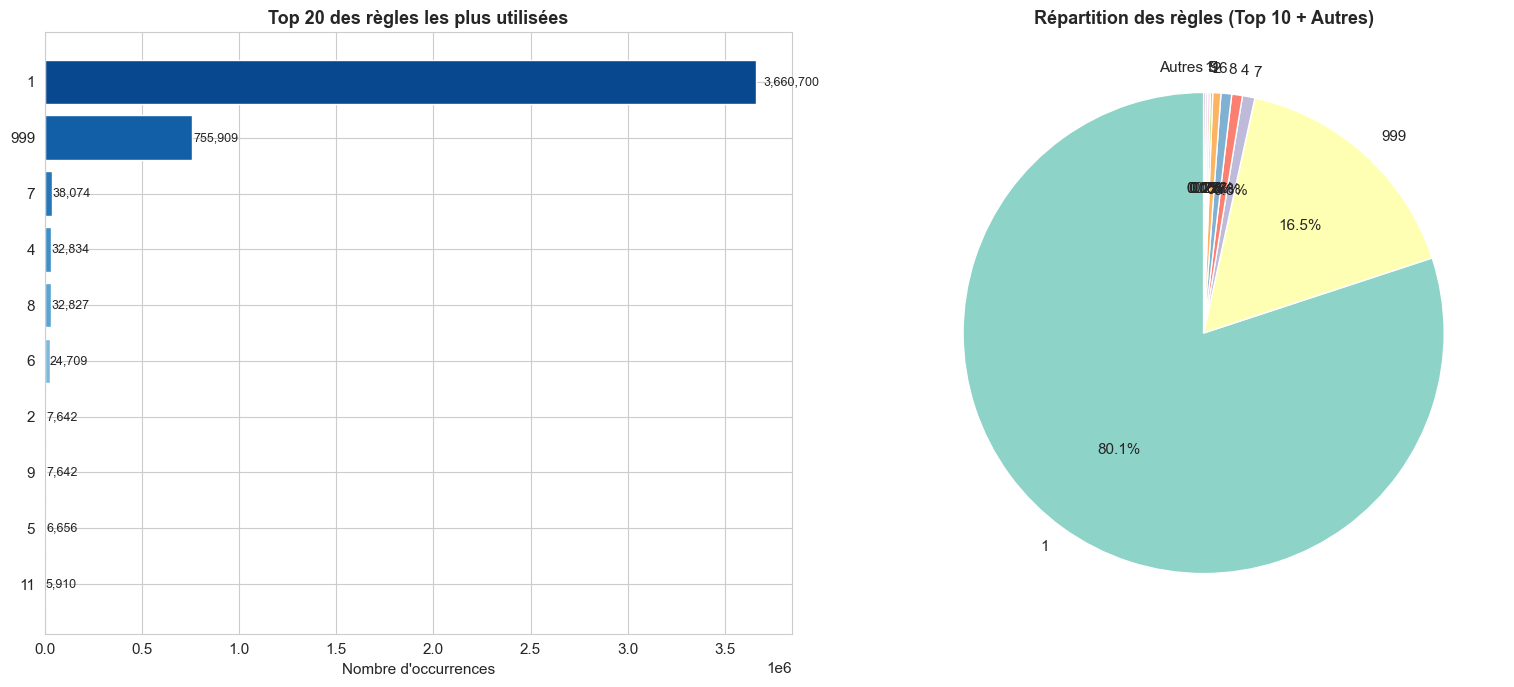


📋 Classement complet des règles :


,Règle (Rule ID),Occurrences,% du total
0,1,3660700,80.05
1,999,755909,16.53
2,7,38074,0.83
3,4,32834,0.72
4,8,32827,0.72
5,6,24709,0.54
6,2,7642,0.17
7,9,7642,0.17
8,5,6656,0.15
9,11,5910,0.13


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
#renomer la colonne taille en rule 
df_filtered.rename(columns={'taille': 'rule'}, inplace=True)

# ── Tableau complet des règles ─────────────────────────────────────────────
if 'rule' in df_filtered.columns:
    rule_counts = df_filtered['rule'].value_counts().reset_index()
    rule_counts.columns = ['Règle (Rule ID)', 'Occurrences']
    rule_counts['% du total'] = (rule_counts['Occurrences'] / len(df_filtered) * 100).round(2)

    # Top 20 pour le graphique
    top20 = rule_counts.head(20)

    # Graphique 1 : barplot horizontal
    bars = axes[0].barh(
        top20['Règle (Rule ID)'].astype(str),
        top20['Occurrences'],
        color=sns.color_palette('Blues_r', len(top20))
    )
    axes[0].set_xlabel('Nombre d\'occurrences')
    axes[0].set_title('Top 20 des règles les plus utilisées', fontweight='bold', fontsize=13)
    axes[0].invert_yaxis()
    for bar, val in zip(bars, top20['Occurrences']):
        axes[0].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                    f'{val:,}', va='center', fontsize=9)

    # Graphique 2 : pie chart top 10
    top10 = rule_counts.head(10)
    other_count = rule_counts.iloc[10:]['Occurrences'].sum()
    pie_data = list(top10['Occurrences']) + [other_count]
    pie_labels = [str(r) for r in top10['Règle (Rule ID)']] + ['Autres']
    axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                colors=sns.color_palette('Set3', len(pie_data)), startangle=90)
    axes[1].set_title('Répartition des règles (Top 10 + Autres)', fontweight='bold', fontsize=13)

    plt.tight_layout()
    plt.savefig('/tmp/ch1_regles.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n📋 Classement complet des règles :')
    display(rule_counts.head(30))
else:
    print('⚠️  Colonne "rule" non trouvée. Vérifier le nom dans le fichier.')
    print('Colonnes disponibles :', df_filtered.columns.tolist())

---
## Chapitre 2 — Histogramme des protocoles utilisés

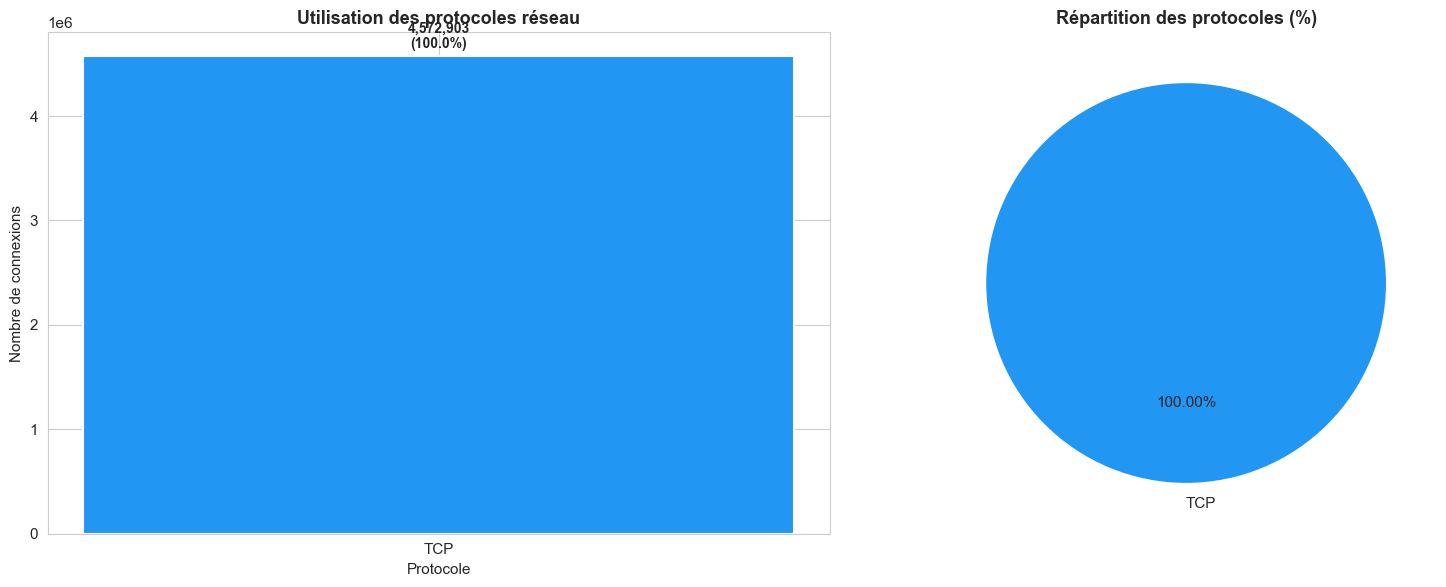

protocole
TCP    4572903
Name: count, dtype: int64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

proto_counts = df_filtered['protocole'].value_counts()
colors_proto = {'TCP': '#2196F3', 'UDP': '#FF9800', 'ICMP': '#4CAF50', 'Autre': '#9E9E9E'}
bar_colors = [colors_proto.get(p, '#9E9E9E') for p in proto_counts.index]

# Histogramme
bars = axes[0].bar(proto_counts.index, proto_counts.values, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Utilisation des protocoles réseau', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Protocole')
axes[0].set_ylabel('Nombre de connexions')
for bar, val in zip(bars, proto_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:,}\n({val/len(df_filtered)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(proto_counts.values, labels=proto_counts.index,
            colors=bar_colors, autopct='%1.2f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Répartition des protocoles (%)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('/tmp/ch2_protocoles.png', dpi=150, bbox_inches='tight')
plt.show()
print(proto_counts)

---
## Chapitre 3 — Top 10 des règles les plus utilisées avec le protocole UDP

In [21]:
df_udp = df_filtered[df_filtered['protocole'] == 'UDP'].copy()
print(f' Nombre de lignes UDP : {len(df_udp):,}')

if 'rule' in df_udp.columns and len(df_udp) > 0:
    top10_udp = df_udp['rule'].value_counts().head(10).reset_index()
    top10_udp.columns = ['Règle (Rule ID)', 'Occurrences UDP']
    top10_udp['% UDP'] = (top10_udp['Occurrences UDP'] / len(df_udp) * 100).round(2)

    fig, ax = plt.subplots(figsize=(13, 6))
    palette = sns.color_palette('Oranges_r', 10)
    bars = ax.barh(top10_udp['Règle (Rule ID)'].astype(str),
                   top10_udp['Occurrences UDP'], color=palette)
    ax.set_title('Top 10 des règles les plus utilisées — Protocole UDP',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel('Nombre d\'occurrences')
    ax.invert_yaxis()
    for bar, (_, row) in zip(bars, top10_udp.iterrows()):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
               f"{row['Occurrences UDP']:,} ({row['% UDP']}%)",
               va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('/tmp/ch3_top10_udp.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n Tableau Top 10 UDP :')
    display(top10_udp)

 Nombre de lignes UDP : 0


---
## Chapitre 4 — Top 5 des règles les plus utilisées avec le protocole TCP

📦 Nombre de lignes TCP : 4,572,903


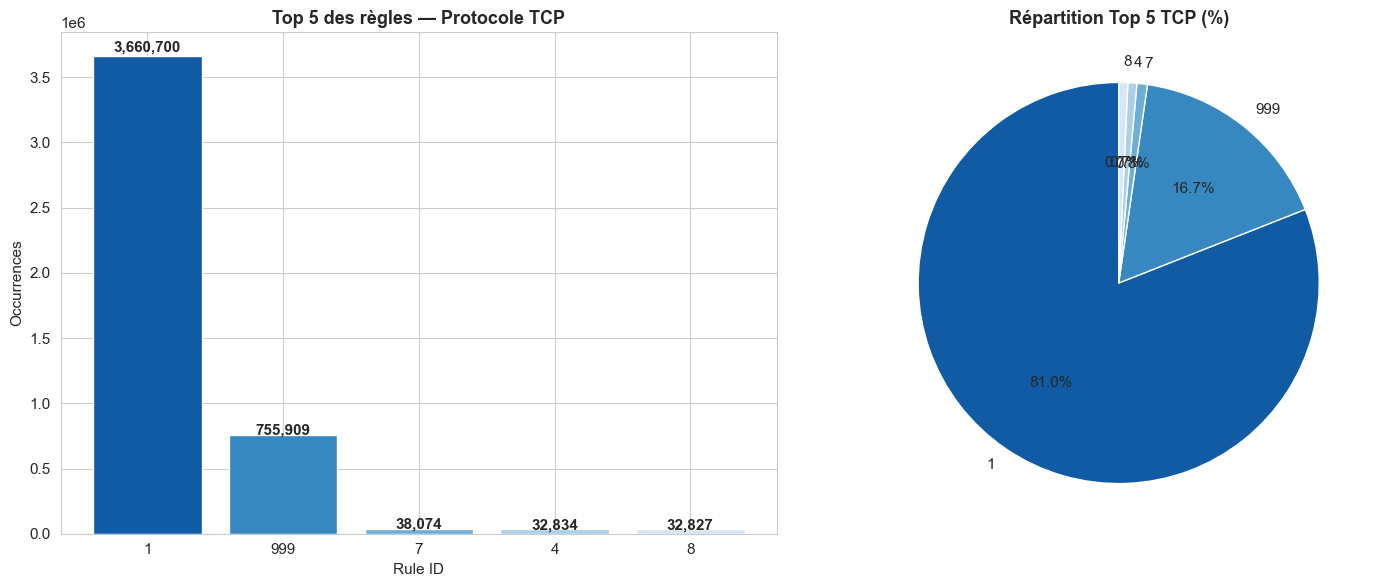


📋 Tableau Top 5 TCP :


,Règle (Rule ID),Occurrences TCP,% TCP
0,1,3660700,80.05
1,999,755909,16.53
2,7,38074,0.83
3,4,32834,0.72
4,8,32827,0.72


In [22]:
df_tcp = df_filtered[df_filtered['protocole'] == 'TCP'].copy()
print(f'📦 Nombre de lignes TCP : {len(df_tcp):,}')

if 'rule' in df_tcp.columns and len(df_tcp) > 0:
    top5_tcp = df_tcp['rule'].value_counts().head(5).reset_index()
    top5_tcp.columns = ['Règle (Rule ID)', 'Occurrences TCP']
    top5_tcp['% TCP'] = (top5_tcp['Occurrences TCP'] / len(df_tcp) * 100).round(2)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Barplot
    palette = sns.color_palette('Blues_r', 5)
    bars = axes[0].bar(top5_tcp['Règle (Rule ID)'].astype(str),
                       top5_tcp['Occurrences TCP'], color=palette, edgecolor='white')
    axes[0].set_title('Top 5 des règles — Protocole TCP', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Rule ID')
    axes[0].set_ylabel('Occurrences')
    for bar, (_, row) in zip(bars, top5_tcp.iterrows()):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f"{row['Occurrences TCP']:,}", ha='center', fontweight='bold')

    # Pie
    axes[1].pie(top5_tcp['Occurrences TCP'],
                labels=top5_tcp['Règle (Rule ID)'].astype(str),
                autopct='%1.1f%%', colors=palette, startangle=90)
    axes[1].set_title('Répartition Top 5 TCP (%)', fontweight='bold', fontsize=13)

    plt.tight_layout()
    plt.savefig('/tmp/ch4_top5_tcp.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n📋 Tableau Top 5 TCP :')
    display(top5_tcp)

---
## Chapitre 5 — Rapprochement règles / ports destination / actions (TCP uniquement)

In [25]:
df_tcp.head()

,timestamp,src_ip,dst_ip,protocole,src_port,dst_port,rule,action,interface,col10,col11
7424749,2025-11-12 09:56:37,77.90.185.64,159.84.146.99,TCP,55366,65153,999,DENY,eth0,,6\n
7424750,2025-11-12 09:56:37,47.128.20.252,159.84.146.99,TCP,14436,443,1,PERMIT,eth0,,6\n
7424751,2025-11-12 09:56:38,23.22.35.162,159.84.146.99,TCP,55973,443,1,PERMIT,eth0,,6\n
7424752,2025-11-12 09:56:39,79.124.60.150,159.84.146.99,TCP,53744,56283,999,DENY,eth0,,6\n
7424753,2025-11-12 09:56:39,47.128.20.252,159.84.146.99,TCP,25404,443,1,PERMIT,eth0,,6\n


📋 Tableau croisé : Règle × Port × Action (TCP uniquement) :


action          DENY   PERMIT    TOTAL
rule dst_port                         
1    443           0  3621944  3621944
     80            0    38756    38756
7    23        38074        0    38074
4    22            0    32834    32834
8    22            0    32827    32827
6    445       20301        0    20301
2    3306          0     7642     7642
9    3306          0     7642     7642
999  8080       7129        0     7129
5    21         6076        0     6076
11   110           0     5910     5910
6    3389       4058        0     4058

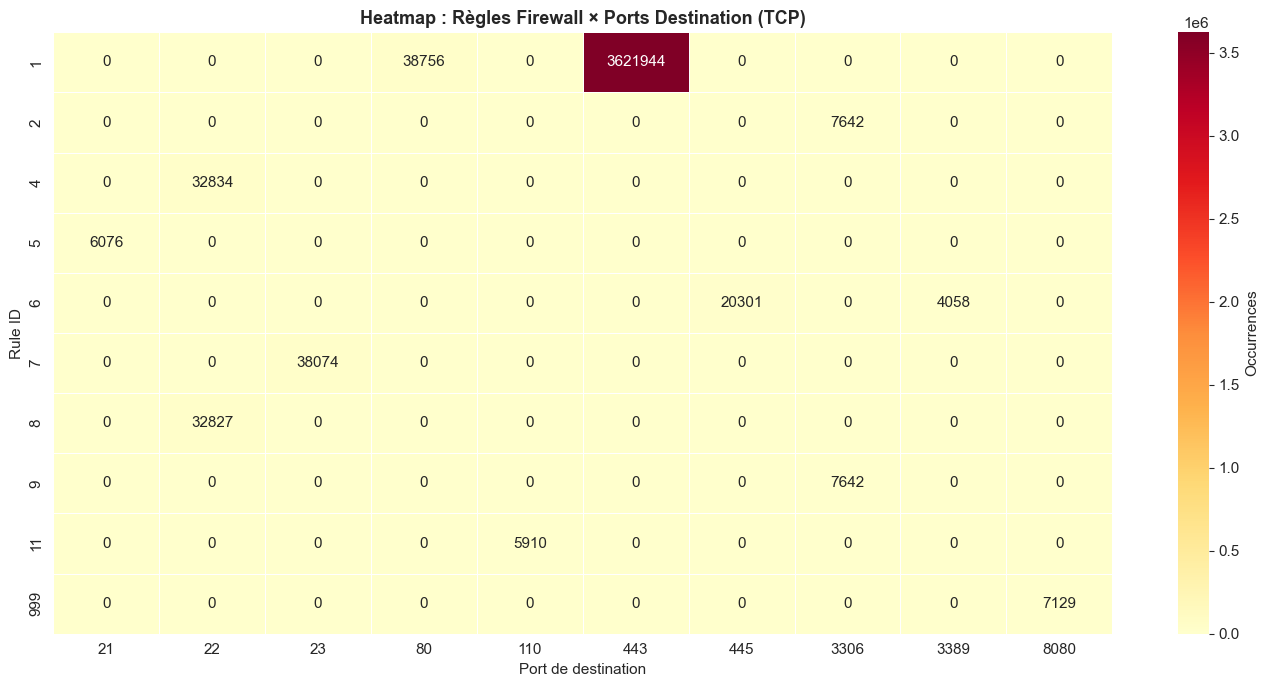

In [ ]:
df_tcp_analysis = df_tcp.copy()

# Convertir les colonnes en numérique
df_tcp_analysis['dst_port'] = pd.to_numeric(df_tcp_analysis['dst_port'], errors='coerce')
df_tcp_analysis['rule'] = pd.to_numeric(df_tcp_analysis['rule'], errors='coerce')

# Top 10 ports les plus fréquents en TCP
top_ports = df_tcp_analysis['dst_port'].value_counts().head(10).index.tolist()
df_cross = df_tcp_analysis[df_tcp_analysis['dst_port'].isin(top_ports)]

# ── Tableau croisé : Rule × Port × Action ─────────────────────────────────
pivot_table = df_cross.groupby(['rule', 'dst_port', 'action']).size().unstack(fill_value=0)
pivot_table['TOTAL'] = pivot_table.sum(axis=1) 
pivot_table = pivot_table.sort_values('TOTAL', ascending=False)

print(' Tableau croisé : Règle × Port × Action (TCP uniquement) :')
display(pivot_table.head(30))

# ── Heatmap : Top 10 règles × Top 10 ports ────────────────────────────────
top_rules = df_tcp_analysis['rule'].value_counts().head(10).index.tolist()

df_heat = df_tcp_analysis[
    df_tcp_analysis['rule'].isin(top_rules) &
    df_tcp_analysis['dst_port'].isin(top_ports)
]

heat_data = df_heat.groupby(['rule', 'dst_port']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heat_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Occurrences'}
)
ax.set_title('Heatmap : Règles Firewall × Ports Destination (TCP)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Port de destination')
ax.set_ylabel('Rule ID')
plt.tight_layout()
plt.savefig('ch5_heatmap_regles_ports.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chapitre 6 — Graphiques de sécurité des Systèmes d'Information

In [31]:
df_filtered.head(3)

,timestamp,src_ip,dst_ip,protocole,src_port,dport,rule,action,interface,col10,col11,heure,jour_semaine
7424749,2025-11-12 09:56:37,77.90.185.64,159.84.146.99,TCP,55366,65153,999,DENY,eth0,,6\n,9,Wednesday
7424750,2025-11-12 09:56:37,47.128.20.252,159.84.146.99,TCP,14436,443,1,PERMIT,eth0,,6\n,9,Wednesday
7424751,2025-11-12 09:56:38,23.22.35.162,159.84.146.99,TCP,55973,443,1,PERMIT,eth0,,6\n,9,Wednesday


In [ ]:
# ── 6.3 Top ports de destination les plus ciblés ───────────────────────────
if 'dport' in df_filtered.columns:
    df_filtered['dport_num'] = pd.to_numeric(df_filtered['dport'], errors='coerce')
    top_dport = df_filtered['dport_num'].value_counts().head(15)
    port_labels = [f"{int(p)} ({PORT_NAMES.get(int(p), 'Inconnu')})" for p in top_dport.index]

    fig, ax = plt.subplots(figsize=(13, 6))
    bars = ax.barh(port_labels, top_dport.values,
                   color=sns.color_palette('RdYlGn_r', len(top_dport)))
    ax.set_title('Top 15 des ports de destination les plus ciblés',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel('Nombre de connexions')
    ax.invert_yaxis()
    for bar, val in zip(bars, top_dport.values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
               f'{val:,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('/tmp/ch6_3_top_ports.png', dpi=150, bbox_inches='tight')
    plt.show()

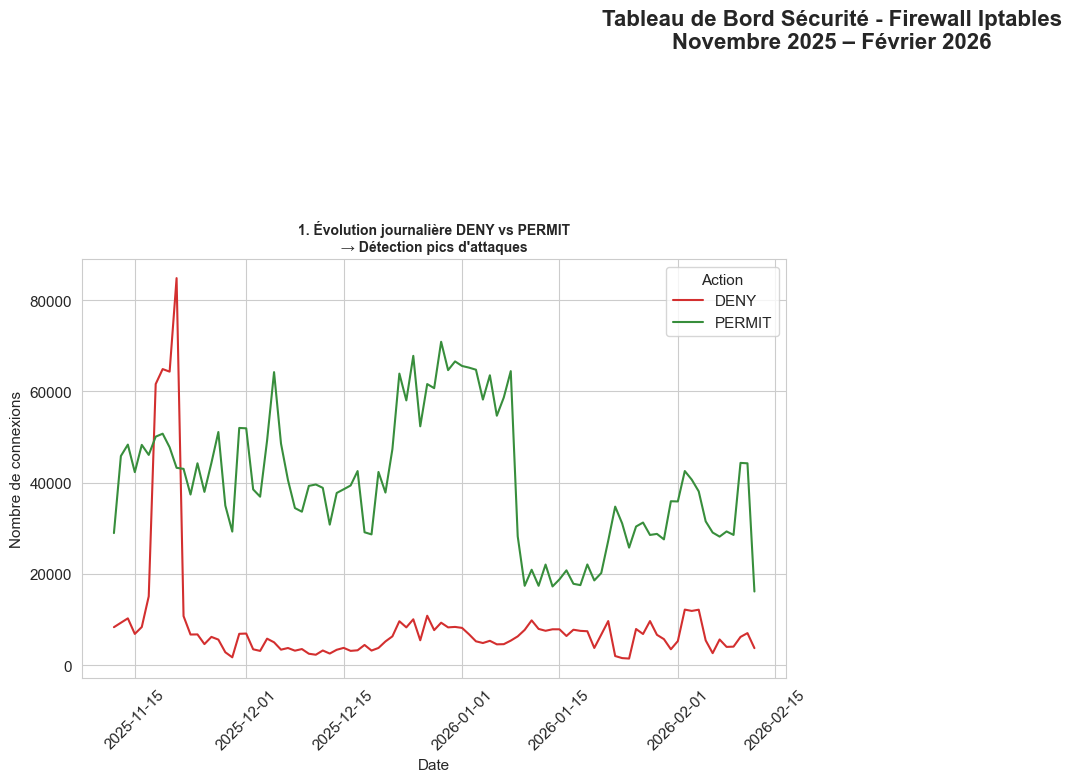

In [33]:
fig = plt.figure(figsize=(20, 25))
fig.suptitle('Tableau de Bord Sécurité - Firewall Iptables\nNovembre 2025 – Février 2026',
             fontsize=16, fontweight='bold', y=0.98)

# ═══════════════════════════════════════════════════════════════
# GRAPHIQUE 1 : Évolution temporelle DENY vs PERMIT par jour
# → Détecter des pics d'attaques
# ═══════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(4, 2, 1)
df_filtered['date_jour'] = pd.to_datetime(df_filtered['timestamp']).dt.date
daily_action = df_filtered.groupby(['date_jour', 'action']).size().unstack(fill_value=0)
daily_action.plot(ax=ax1, color={'DENY': '#D32F2F', 'PERMIT': '#388E3C'}, linewidth=1.5)
ax1.set_title('1. Évolution journalière DENY vs PERMIT\n→ Détection pics d\'attaques',
              fontweight='bold', fontsize=10)
ax1.set_xlabel('Date')
ax1.set_ylabel('Nombre de connexions')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Action')


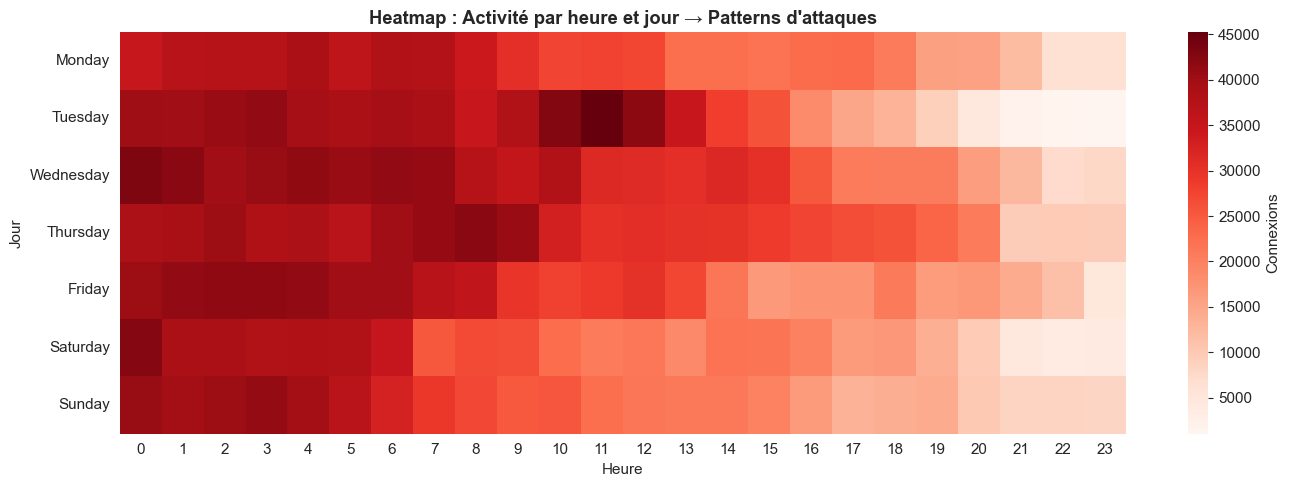

In [35]:
# ── CELLULE 3 : Graphique 2 — Heatmap heure × jour ───────────
jour_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat_time = df_filtered.groupby(['jour_semaine', 'heure']).size().unstack(fill_value=0)
heat_time = heat_time.reindex([j for j in jour_order if j in heat_time.index])

plt.figure(figsize=(14, 5))
sns.heatmap(heat_time, cmap='Reds', fmt='d',
            cbar_kws={'label': 'Connexions'})
plt.title('Heatmap : Activité par heure et jour → Patterns d\'attaques',
          fontweight='bold')
plt.xlabel('Heure')
plt.ylabel('Jour')
plt.tight_layout()
plt.savefig('g2_heatmap_temps.png', dpi=150)
plt.show()

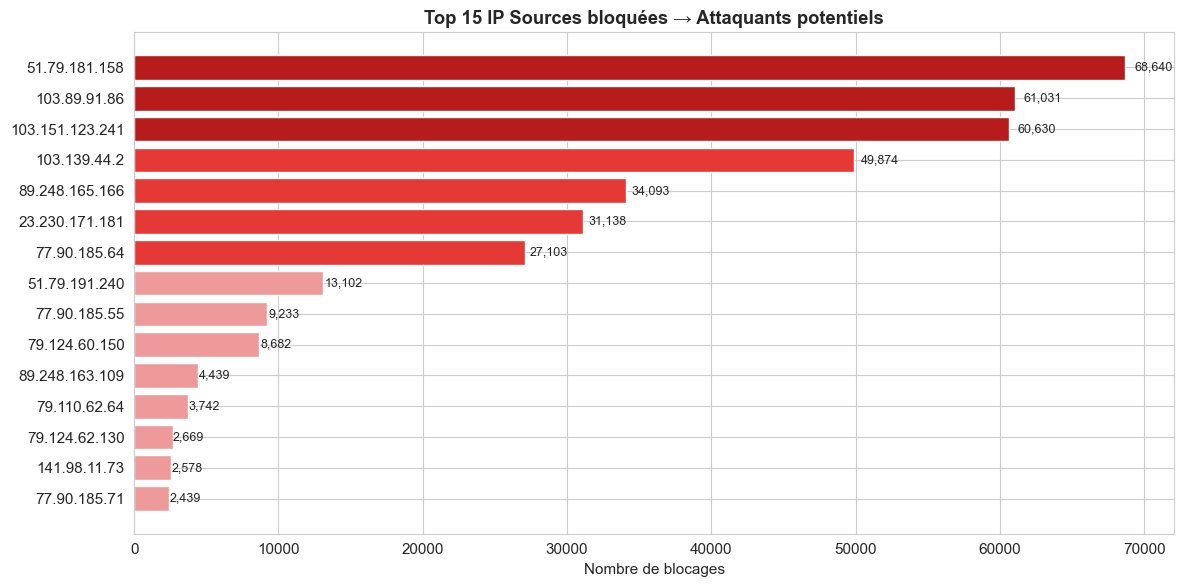

In [37]:
# ── CELLULE 4 : Graphique 3 — Top 15 IP bloquées ─────────────
top_deny_ip = (df_filtered[df_filtered['action'] == 'DENY']['src_ip']
               .value_counts().head(15))

colors_ip = ['#B71C1C' if i < 3 else '#E53935' if i < 7 else '#EF9A9A'
             for i in range(len(top_deny_ip))]

fig, ax = plt.subplots()
bars = ax.barh(top_deny_ip.index, top_deny_ip.values, color=colors_ip)
ax.set_title('Top 15 IP Sources bloquées → Attaquants potentiels', fontweight='bold')
ax.set_xlabel('Nombre de blocages')
ax.invert_yaxis()
for bar, val in zip(bars, top_deny_ip.values):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('g3_top_ip_deny.png', dpi=150)
plt.show()

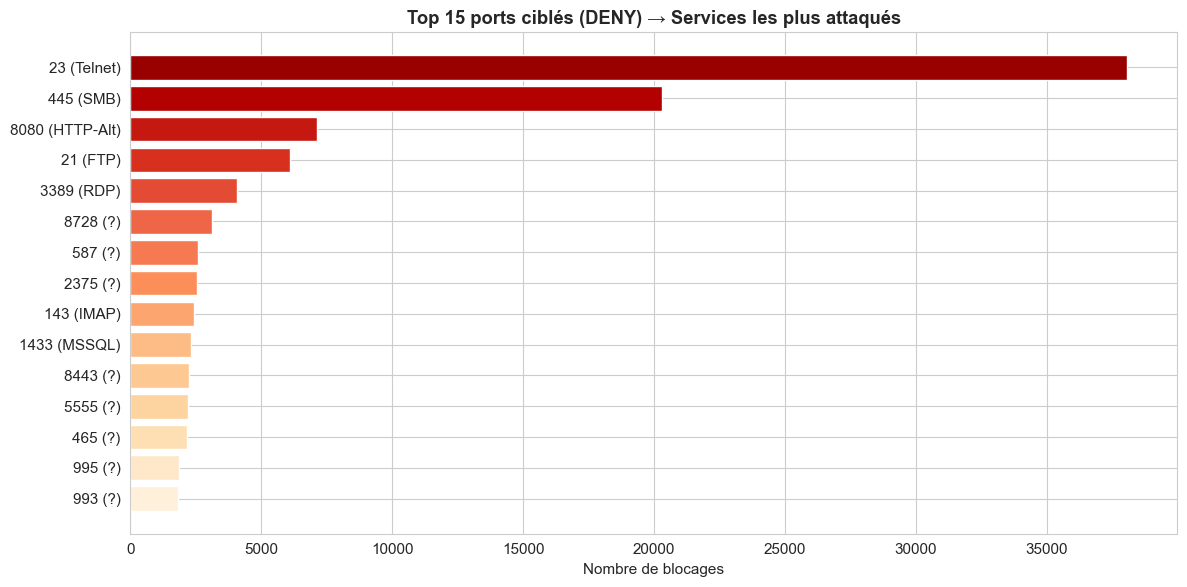

In [38]:
# ═══════════════════════════════════════════════════════════════
# GRAPHIQUE 4 : Top 15 ports destination les plus ciblés
# → Voir quels services sont attaqués
# ═══════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(4, 2, 4)
PORT_NAMES = {
    20:'FTP-data', 21:'FTP', 22:'SSH', 23:'Telnet',
    25:'SMTP', 53:'DNS', 80:'HTTP', 110:'POP3',
    143:'IMAP', 443:'HTTPS', 445:'SMB', 1433:'MSSQL',
    3306:'MySQL', 3389:'RDP', 8080:'HTTP-Alt', 65153:'Inconnu'
}
# ── CELLULE 5 : Graphique 4 — Top ports ciblés ───────────────
top_ports_deny = (df_filtered[df_filtered['action'] == 'DENY']['dport']
                  .value_counts().head(15))
port_labels = [f"{int(p)} ({PORT_NAMES.get(int(p), '?')})"
               if str(p).isdigit() else str(p) for p in top_ports_deny.index]

fig, ax = plt.subplots()
ax.barh(port_labels, top_ports_deny.values,
        color=sns.color_palette('OrRd_r', len(top_ports_deny)))
ax.set_title('Top 15 ports ciblés (DENY) → Services les plus attaqués', fontweight='bold')
ax.set_xlabel('Nombre de blocages')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('g4_top_ports.png', dpi=150)
plt.show()

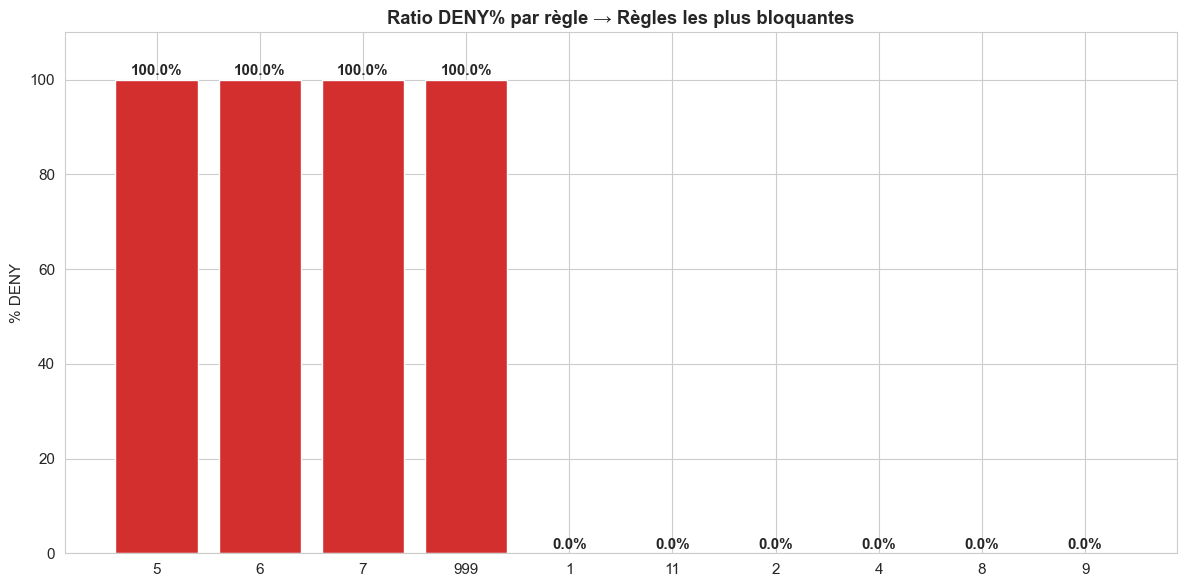

In [39]:
# ── CELLULE 6 : Graphique 5 — Ratio DENY% par règle ──────────
rule_action = df_filtered.groupby(['rule', 'action']).size().unstack(fill_value=0)
rule_action['RATIO_DENY'] = (rule_action.get('DENY', 0) /
                              rule_action.sum(axis=1) * 100).round(1)
top_rules_ratio = rule_action.nlargest(10, 'RATIO_DENY')

colors_r = ['#D32F2F' if r > 80 else '#FF7043' if r > 50 else '#FFA726'
            for r in top_rules_ratio['RATIO_DENY']]
fig, ax = plt.subplots()
bars = ax.bar(top_rules_ratio.index.astype(str),
              top_rules_ratio['RATIO_DENY'], color=colors_r)
ax.set_title('Ratio DENY% par règle → Règles les plus bloquantes', fontweight='bold')
ax.set_ylabel('% DENY')
ax.set_ylim(0, 110)
for bar, val in zip(bars, top_rules_ratio['RATIO_DENY']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('g5_ratio_deny.png', dpi=150)
plt.show()

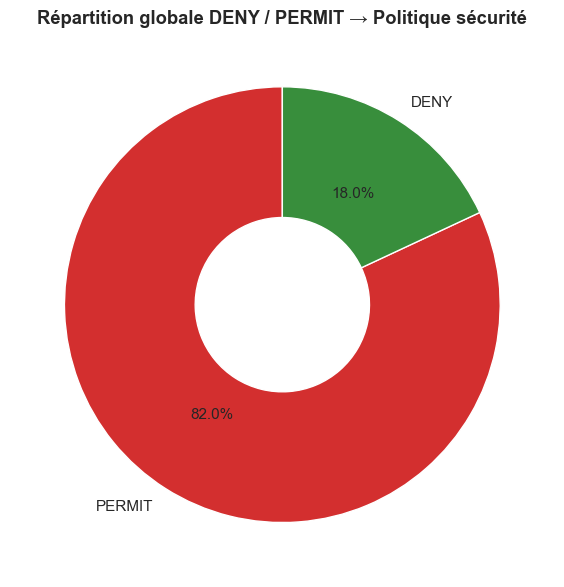

In [40]:
# ── CELLULE 7 : Graphique 6 — Donut DENY/PERMIT ──────────────
action_counts = df_filtered['action'].value_counts()

fig, ax = plt.subplots()
ax.pie(action_counts.values, labels=action_counts.index,
       autopct='%1.1f%%', colors=['#D32F2F','#388E3C'],
       startangle=90, wedgeprops={'width': 0.6})
ax.set_title('Répartition globale DENY / PERMIT → Politique sécurité', fontweight='bold')
plt.tight_layout()
plt.savefig('g6_donut.png', dpi=150)
plt.show()